In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/raw/india_housing_prices.csv")
df.shape
print(df.head(5))

   ID        State      City      Locality      Property_Type  BHK  \
0   1   Tamil Nadu   Chennai   Locality_84          Apartment    1   
1   2  Maharashtra      Pune  Locality_490  Independent House    3   
2   3       Punjab  Ludhiana  Locality_167          Apartment    2   
3   4    Rajasthan   Jodhpur  Locality_393  Independent House    2   
4   5    Rajasthan    Jaipur  Locality_466              Villa    4   

   Size_in_SqFt  Price_in_Lakhs  Price_per_SqFt  Year_Built  ...  \
0          4740          489.76            0.10        1990  ...   
1          2364          195.52            0.08        2008  ...   
2          3642          183.79            0.05        1997  ...   
3          2741          300.29            0.11        1991  ...   
4          4823          182.90            0.04        2002  ...   

  Age_of_Property  Nearby_Schools  Nearby_Hospitals  \
0              35              10                 3   
1              17               8                 1   
2    

In [2]:
# Basic Info
print(df.info())
print("\nDescribe:")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors    

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,125000.500000,2.999396,2749.813216,254.586854,0.130597,2006.520012,14.966800,15.503004,18.479988,5.499860,5.498016
std,72168.927986,1.415521,1300.606954,141.349921,0.130747,9.808575,8.948047,8.671618,9.808575,2.878639,2.871860
min,1.000000,1.000000,500.000000,10.000000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,62500.750000,2.000000,1623.000000,132.550000,0.050000,1998.000000,7.000000,8.000000,10.000000,3.000000,3.000000
50%,125000.500000,3.000000,2747.000000,253.870000,0.090000,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,187500.250000,4.000000,3874.000000,376.880000,0.160000,2015.000000,23.000000,23.000000,27.000000,8.000000,8.000000
max,250000.000000,5.000000,5000.000000,500.000000,0.990000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


In [3]:
# ── Check Missing Values ──────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []


In [4]:
# ── Fill Missing Values ───────────────────────────────────────
# For numerical columns → fill with median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# For categorical columns → fill with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing after cleaning:", df.isnull().sum().sum())

Missing after cleaning: 0


In [5]:
# ── Remove Outliers using IQR ─────────────────────────────────
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]
print("Shape after outlier removal:", df.shape)

Shape after outlier removal: (229980, 23)


In [6]:
from sklearn.preprocessing import LabelEncoder

# ── Encode Categorical Columns ────────────────────────────────
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("Encoding done! Shape:", df.shape)
df.head()

Encoding done! Shape: (229980, 23)


,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,15,6,483,0,1,4740,489.76,0.10,1990,...,35,10,3,0,0,0,238,3,2,0
1,2,11,33,434,1,3,2364,195.52,0.08,2008,...,17,8,1,1,0,1,211,1,1,1
2,3,13,25,75,0,2,3642,183.79,0.05,1997,...,28,9,8,1,1,0,63,2,0,0
3,4,14,21,326,1,2,2741,300.29,0.11,1991,...,34,5,7,0,1,1,206,1,1,0
4,5,14,19,407,2,4,4823,182.90,0.04,2002,...,23,4,9,1,0,1,222,0,1,0


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Clean column names (good practice)
df.columns = df.columns.str.strip()

# Correct target column
TARGET = 'Price_in_Lakhs'

# Features & target
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Convert categorical data
X = pd.get_dummies(X)

# Handle missing values
X = X.fillna(0)
y = y.fillna(0)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (183984, 22) | Test: (45996, 22)


In [8]:
# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Model Evaluation Metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# Model Initialization
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    ),
    "XGBoost": XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        objective='reg:squarederror'
    )
}


# Store Evaluation Results
results = []


# Train and Evaluate Models
for name, model in models.items():

    # Train model on training data
    model.fit(X_train, y_train)

    # Generate predictions on test data
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Store model performance
    results.append({
        'Model': name,
        'R2 Score': round(r2, 4),
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2)
    })

    # Print model performance
    print(
        f"{name:25s} → "
        f"R²: {r2:.4f} | "
        f"MAE: {mae:.2f} | "
        f"RMSE: {rmse:.2f}"
    )


# Create Results DataFrame
results_df = pd.DataFrame(results)

# Sort models based on R² score
results_df = results_df.sort_values(
    by='R2 Score',
    ascending=False
)

# Display final comparison table
print("\nModel Performance Comparison:")
print(results_df)

Linear Regression         → R²: 0.7379 | MAE: 56.18 | RMSE: 71.53
Ridge Regression          → R²: 0.7379 | MAE: 56.18 | RMSE: 71.53
Lasso Regression          → R²: 0.7379 | MAE: 56.17 | RMSE: 71.53
Decision Tree             → R²: 0.9916 | MAE: 9.59 | RMSE: 12.78
Random Forest             → R²: 0.9957 | MAE: 7.26 | RMSE: 9.20
Gradient Boosting         → R²: 0.9901 | MAE: 11.32 | RMSE: 13.91
XGBoost                   → R²: 0.9957 | MAE: 7.35 | RMSE: 9.18

Model Performance Comparison:
               Model  R2 Score    MAE   RMSE
4      Random Forest    0.9957   7.26   9.20
6            XGBoost    0.9957   7.35   9.18
3      Decision Tree    0.9916   9.59  12.78
5  Gradient Boosting    0.9901  11.32  13.91
2   Lasso Regression    0.7379  56.17  71.53
0  Linear Regression    0.7379  56.18  71.53
1   Ridge Regression    0.7379  56.18  71.53


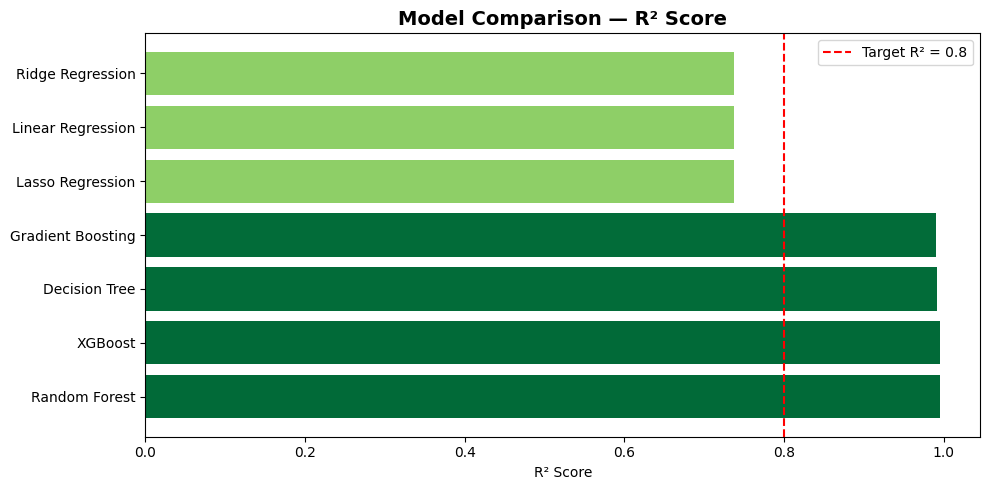

Figure saved successfully at:
D:\End-To-End-House-Data-Analysis\End_To_End_House_Price_Prediction\reports\figures\r2_comparison.png


In [9]:
# ── Graph 1: R2 Score Comparison ──────────────────────────────

# Define save path
save_path = r"D:\End-To-End-House-Data-Analysis\End_To_End_House_Price_Prediction\reports\figures\r2_comparison.png"

# Create figure
plt.figure(figsize=(10, 5))

# Create horizontal bar plot
bars = plt.barh(
    results_df['Model'],
    results_df['R2 Score'],
    color=plt.cm.RdYlGn(results_df['R2 Score'])
)

# Customize plot
plt.xlabel('R² Score')
plt.title(
    'Model Comparison — R² Score',
    fontsize=14,
    fontweight='bold'
)

# Add target R² reference line
plt.axvline(
    x=0.8,
    color='red',
    linestyle='--',
    label='Target R² = 0.8'
)

# Display legend
plt.legend()

# Adjust layout
plt.tight_layout()

# Save figure to reports/figures folder
plt.savefig(
    save_path,
    dpi=300,
    bbox_inches='tight'
)

# Display plot
plt.show()

print(f"Figure saved successfully at:\n{save_path}")

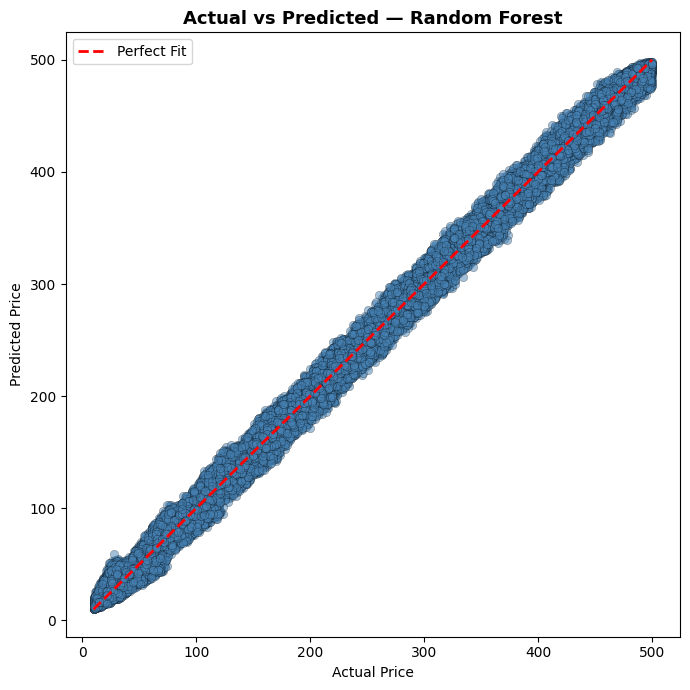

Figure saved successfully at:D:\End-To-End-House-Data-Analysis\End_To_End_House_Price_Prediction\reports\figures\actual_vs_predictive.png


In [10]:
# ── Graph 2: Actual vs Predicted (Best Model) ─────────────────

# Select the best model based on R² score
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

# Generate predictions using the best model
y_pred_best = best_model.predict(X_test)

# Create scatter plot
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred_best,
    alpha=0.5,
    color='steelblue',
    edgecolors='k',
    linewidths=0.3
)

# Plot perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2,
    label='Perfect Fit'
)

# Customize the plot
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(
    f'Actual vs Predicted — {best_model_name}',
    fontsize=13,
    fontweight='bold'
)

plt.legend()
plt.tight_layout()

save_path = r"D:\End-To-End-House-Data-Analysis\End_To_End_House_Price_Prediction\reports\figures\actual_vs_predictive.png"
# Save the figure
plt.savefig(
    save_path,
    dpi=300,
    bbox_inches='tight'
)

# Display the plot
plt.show()

print(
    f"Figure saved successfully at:{save_path}"
)

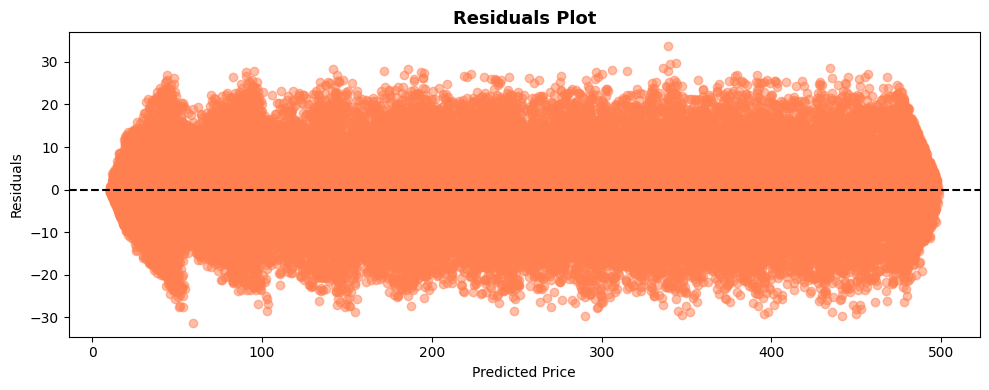

Figure saved successfully at:D:\End-To-End-House-Data-Analysis\End_To_End_House_Price_Prediction\reports\figures\Residual_plot.png


In [11]:
# ── Graph 3: Residuals Plot ───────────────────────────────────

# Calculate residuals
residuals = y_test - y_pred_best

# Create residual plot
plt.figure(figsize=(10, 4))

plt.scatter(
    y_pred_best,
    residuals,
    alpha=0.5,
    color='coral'
)

# Add reference line at zero residual
plt.axhline(
    y=0,
    color='black',
    linestyle='--'
)

# Customize plot
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title(
    'Residuals Plot',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()


save_path = r"D:\End-To-End-House-Data-Analysis\End_To_End_House_Price_Prediction\reports\figures\Residual_plot.png"
# Save the figure
plt.savefig(
    save_path,
    dpi=300,
    bbox_inches='tight'
)

# Display plot
plt.show()

print(
    f"Figure saved successfully at:{save_path}"
   )

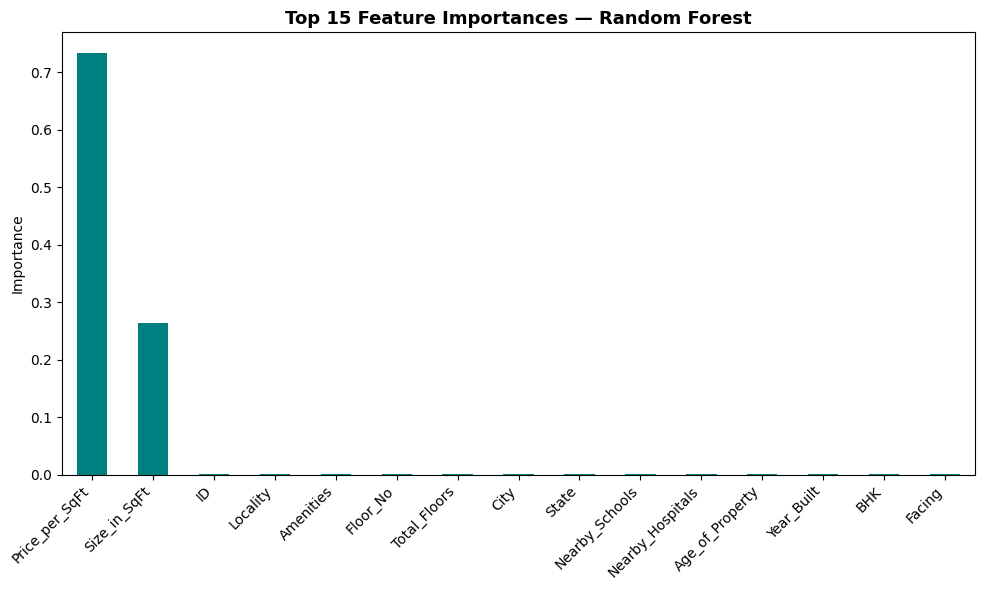

Figure saved successfully at:
D:\End-To-End-House-Data-Analysis\End_To_End_House_Price_Prediction\reports\figures\feature_importance.png


In [12]:
# ── Graph 4: Feature Importance (Random Forest) ───────────────

# Select the trained Random Forest model
rf_model = models["Random Forest"]

# Calculate feature importances
feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=df.drop(columns=[TARGET]).columns
)

# Select top 15 important features
feat_imp = feat_imp.sort_values(ascending=False).head(15)

# Create the plot
plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar', color='teal')

# Customize the plot
plt.title(
    'Top 15 Feature Importances — Random Forest',
    fontsize=13,
    fontweight='bold'
)
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Define save path
save_path = r"D:\End-To-End-House-Data-Analysis\End_To_End_House_Price_Prediction\reports\figures\feature_importance.png"

# Save the figure
plt.savefig(
    save_path,
    dpi=300,
    bbox_inches='tight'
)

# Display the plot
plt.show()

print(f"Figure saved successfully at:\n{save_path}")

Using 23 numeric columns for heatmap
Columns: ['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type', 'Availability_Status']


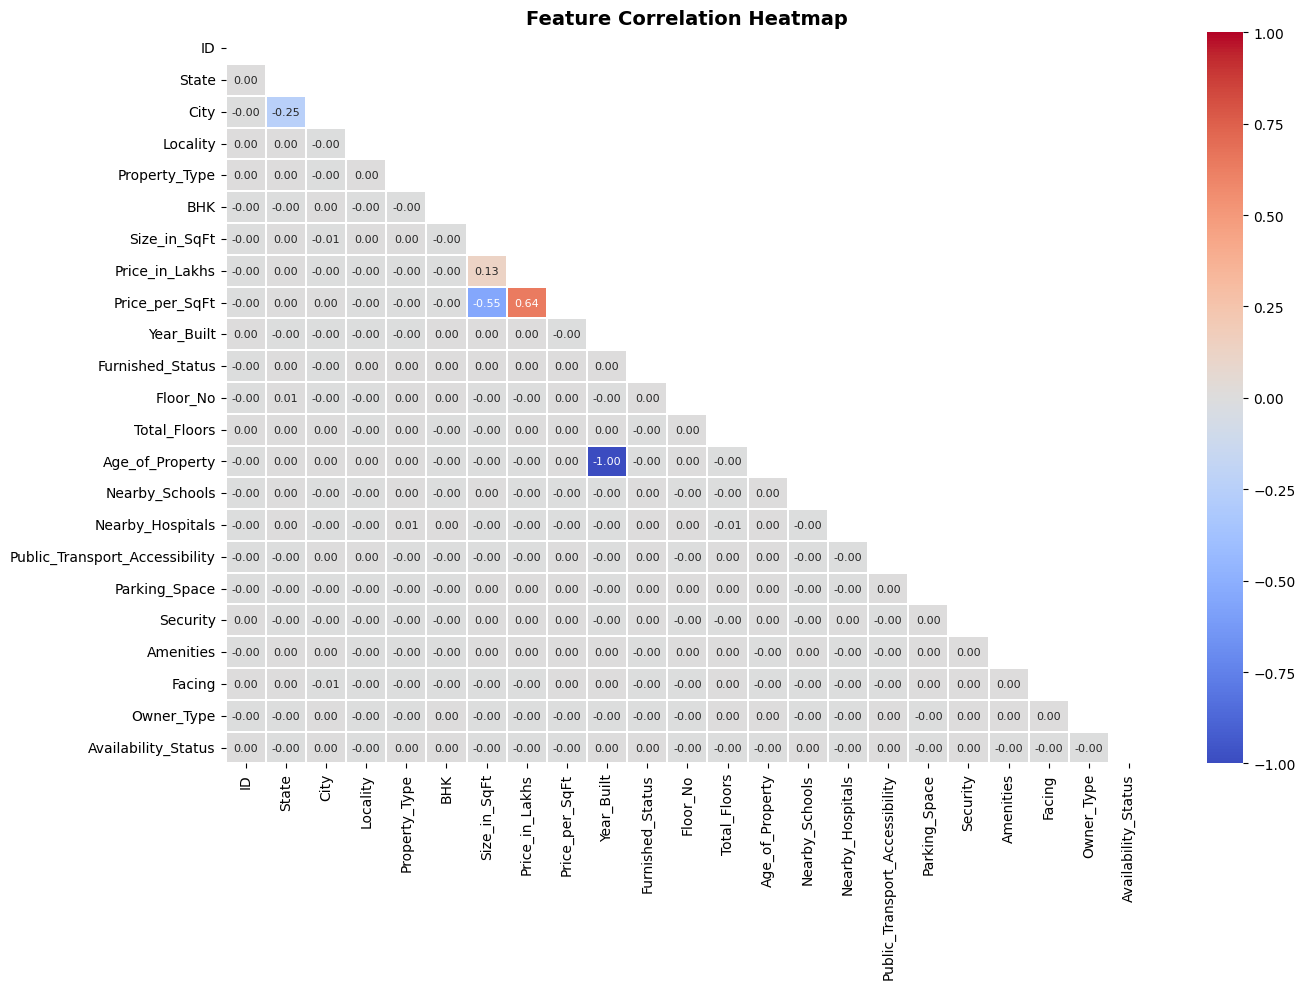

In [13]:
# ── Graph 5: Correlation Heatmap ─────────────────────────────


# Drop datetime/string columns before correlation
df_numeric = df.select_dtypes(include=['float64', 'int64', 'int32', 'float32'])

print(f"Using {df_numeric.shape[1]} numeric columns for heatmap")
print("Columns:", df_numeric.columns.tolist())

plt.figure(figsize=(14, 10))
corr = df_numeric.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,          # shows values inside boxes
    fmt='.2f',           # 2 decimal places
    cmap='coolwarm',
    linewidths=0.3,
    vmin=-1, vmax=1,
    annot_kws={"size": 8}
)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
save_path = r"D:\End-To-End-House-Data-Analysis\End_To_End_House_Price_Prediction\reports\figures\Feature_correalation.png"
plt.savefig(
    save_path,
    dpi=300,
    bbox_inches='tight'
)
plt.show()


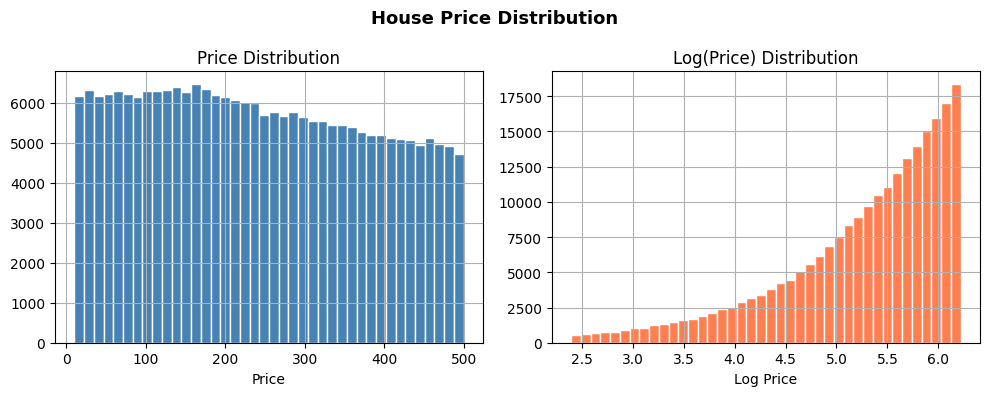

In [14]:
# ── Graph 6: Price Distribution ───────────────────────────────
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df[TARGET].hist(bins=40, color='steelblue', edgecolor='white')
plt.title('Price Distribution')
plt.xlabel('Price')

plt.subplot(1, 2, 2)
np.log1p(df[TARGET]).hist(bins=40, color='coral', edgecolor='white')
plt.title('Log(Price) Distribution')
plt.xlabel('Log Price')

plt.suptitle('House Price Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
save_path = r"D:\End-To-End-House-Data-Analysis\End_To_End_House_Price_Prediction\reports\figures\house_price_dristribution.png"
plt.savefig(
    save_path,
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [15]:
print("=" * 50)
print(f"   Best Model : {results_df.iloc[0]['Model']}")
print(f"   R² Score   : {results_df.iloc[0]['R2 Score']}")
print(f"   MAE        : {results_df.iloc[0]['MAE']}")
print(f"   RMSE       : {results_df.iloc[0]['RMSE']}")
print("=" * 50)

   Best Model : Random Forest
   R² Score   : 0.9957
   MAE        : 7.26
   RMSE       : 9.2


In [17]:
import os
import joblib

save_dir = "../Models"   # your existing folder

for name, model in models.items():
    filename = name.lower().replace(" ", "_") + ".pkl"
    path = os.path.join(save_dir, filename)

    joblib.dump(model, path)

    print(f"Saved {name} to {path}")

Saved Linear Regression to ../Models\linear_regression.pkl
Saved Ridge Regression to ../Models\ridge_regression.pkl
Saved Lasso Regression to ../Models\lasso_regression.pkl
Saved Decision Tree to ../Models\decision_tree.pkl
Saved Random Forest to ../Models\random_forest.pkl
Saved Gradient Boosting to ../Models\gradient_boosting.pkl
Saved XGBoost to ../Models\xgboost.pkl


In [21]:
joblib.dump(list(X.columns), "../Models/features.pkl")

['../Models/features.pkl']

In [22]:


joblib.dump(list(X.columns), "../Models/features.pkl")

['../Models/features.pkl']